# Machine Learning 2025W — Exercise 0  
### Dataset Description and Exploration (adult)

**Group Members:**  
- Full Name 1  
- Full Name 2  
- Full Name 3  

---


## 1. Setup

In [1]:
from scipy.io import arff
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [ ]:
file_path = '../datasets/dataset_adult.arff'

data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)

for col in df.select_dtypes(['object']).columns:
        df[col] = df[col].str.decode('utf-8')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,class
0,2,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K
1,3,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,2,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States,<=50K
3,3,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States,<=50K
4,1,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba,<=50K


## 3. Basic Information

In [16]:
df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  object 
 1   workclass       48842 non-null  object 
 2   fnlwgt          48842 non-null  float64
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  float64
 5   marital-status  48842 non-null  object 
 6   occupation      48842 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capitalgain     48842 non-null  object 
 11  capitalloss     48842 non-null  object 
 12  hoursperweek    48842 non-null  object 
 13  native-country  48842 non-null  object 
 14  class           48842 non-null  object 
dtypes: float64(2), object(13)
memory usage: 5.6+ MB


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capitalgain       0
capitalloss       0
hoursperweek      0
native-country    0
class             0
dtype: int64

In [10]:
df['workclass'].value_counts(dropna=False)
df['occupation'].value_counts(dropna=False)

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
?                    2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [11]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1) Basic counts
n_samples, n_attrs = df.shape
print(f"Samples: {n_samples:,}, Attributes: {n_attrs:,}")

# 2) Per-column diagnostics
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'n_unique': df.nunique(dropna=False)
})

# 3) Heuristic to infer attribute type
def infer_attr_type(col):
    if pd.api.types.is_numeric_dtype(df[col]):
        # numeric: if integer with few unique values -> maybe ordinal; else interval/ratio
        if df[col].nunique(dropna=True) <= 10 and pd.api.types.is_integer_dtype(df[col]):
            return 'ordinal (likely)'
        return 'interval/ratio'
    else:
        # non-numeric -> categorical (nominal)
        return 'nominal (categorical)'

summary['inferred_type'] = [infer_attr_type(c) for c in df.columns]

# show columns sorted by number of missing values (descending)
display(summary.sort_values('n_missing', ascending=False))

Samples: 48,842, Attributes: 15


,dtype,n_missing,n_unique,inferred_type
age,object,0,5,nominal (categorical)
workclass,object,0,9,nominal (categorical)
fnlwgt,float64,0,28523,interval/ratio
education,object,0,16,nominal (categorical)
education-num,float64,0,16,interval/ratio
marital-status,object,0,7,nominal (categorical)
occupation,object,0,15,nominal (categorical)
relationship,object,0,6,nominal (categorical)
race,object,0,5,nominal (categorical)
sex,object,0,2,nominal (categorical)


## 4. Target Variable (Distribution)

Text(0.5, 0, 'Income Class')

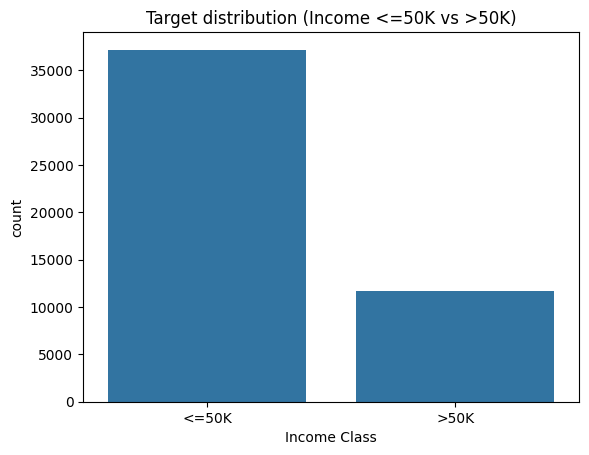

In [ ]:
target_col = 'class'

sns.countplot(x=target_col, data=df)
plt.title('Target distribution (Income <=50K vs >50K)')
plt.xlabel('Income Class (class)')

## 5. Feature Exploration

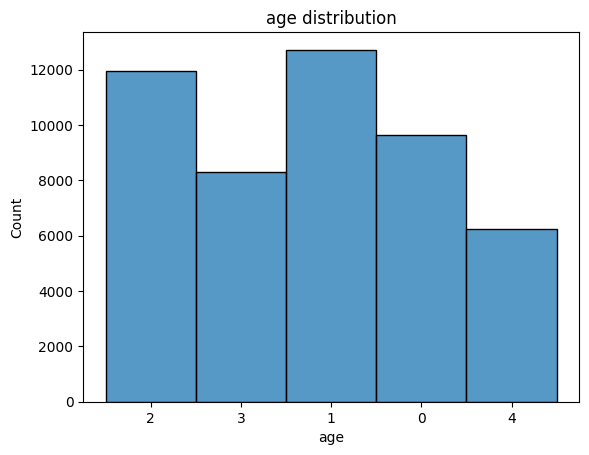

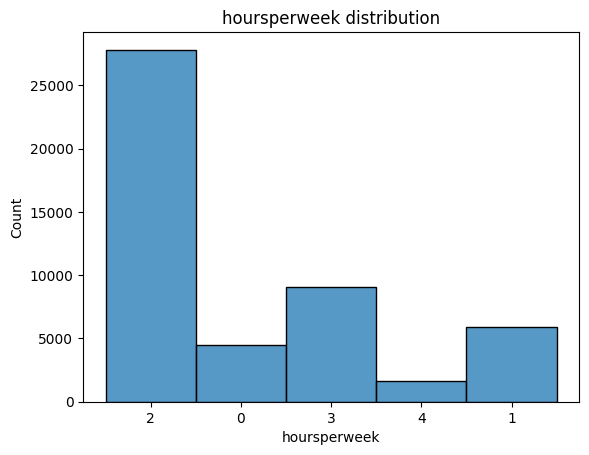

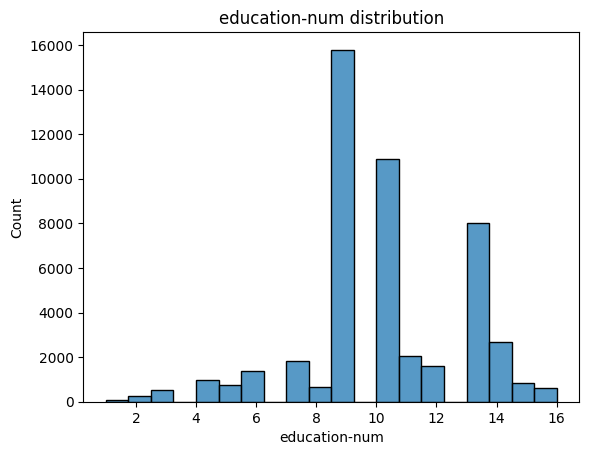

In [18]:
for col in ['age', 'hoursperweek', 'education-num']:
    sns.histplot(df[col], bins=20)
    plt.title(f'{col} distribution')
    plt.show()

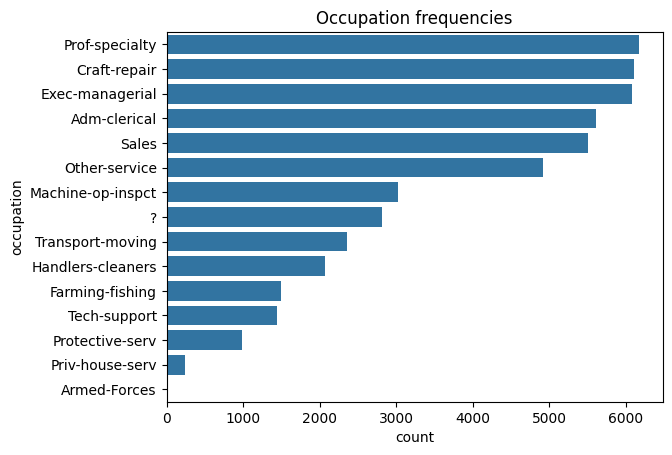

In [19]:
sns.countplot(y='occupation', data=df, order=df['occupation'].value_counts().index)
plt.title('Occupation frequencies')
plt.show()

In [21]:
df.var(numeric_only=True).sort_values(ascending=True)


education-num    6.609901e+00
fnlwgt           1.115221e+10
dtype: float64

In [22]:
for col in df.select_dtypes('object'):
    print(df[col].value_counts(normalize=True).head())

age
1    0.260411
2    0.244707
0    0.197105
3    0.169854
4    0.127923
Name: proportion, dtype: float64
workclass
Private             0.694198
Self-emp-not-inc    0.079071
Local-gov           0.064207
?                   0.057307
State-gov           0.040559
Name: proportion, dtype: float64
education
HS-grad         0.323164
Some-college    0.222718
Bachelors       0.164305
Masters         0.054400
Assoc-voc       0.042197
Name: proportion, dtype: float64
marital-status
Married-civ-spouse    0.458192
Never-married         0.329982
Divorced              0.135805
Separated             0.031325
Widowed               0.031080
Name: proportion, dtype: float64
occupation
Prof-specialty     0.126367
Craft-repair       0.125138
Exec-managerial    0.124606
Adm-clerical       0.114881
Sales              0.112690
Name: proportion, dtype: float64
relationship
Husband          0.403669
Not-in-family    0.257627
Own-child        0.155215
Unmarried        0.104930
Wife             0.047725
Name: p

<Axes: xlabel='workclass', ylabel='count'>

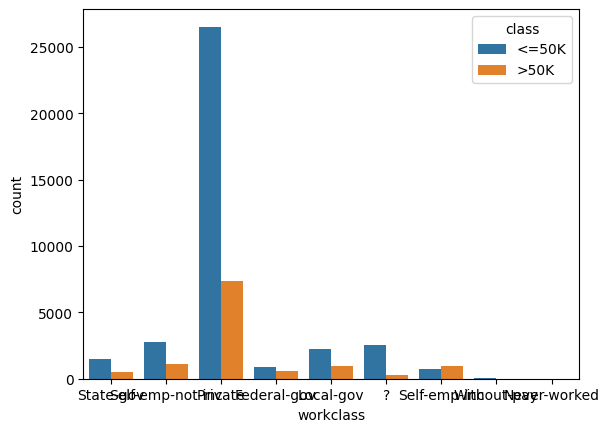

In [28]:
sns.countplot(x='workclass', hue='class', data=df)

## 6. Preprocessing Notes

In [ ]:
# - Handle missing values
# - Normalize / scale numeric features
# - Encode categorical features

# Example: Standard scaling
# scaler = StandardScaler()
# df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)


## 7. Summary

In [ ]:
# Summarize dataset characteristics and preprocessing needs here